# Price Match Gurantee Use case

In [7]:
import shutil  # standard library module for high-level file operations (move, copy, etc.)
from pathlib import Path  # object-oriented filesystem path handling

attachments_dir = Path("data/attachments")  # root folder that currently holds all attachment files mixed together
ext_to_folder = {"doc": "doc", "pdf": "pdf", "jpg": "jpg"}  # maps each file extension we care about to its destination subfolder name

for folder in ext_to_folder.values():  # loop over the three destination folder names ("doc", "pdf", "jpg")
    (attachments_dir / folder).mkdir(exist_ok=True)  # create data/attachments/<folder> if it doesn't already exist; do nothing if it does

moved_counts = {ext: 0 for ext in ext_to_folder}  # running tally of how many files get moved per extension, initialized to 0

for file in attachments_dir.iterdir():  # iterate over every entry directly inside data/attachments (files and folders)
    if file.is_file():  # skip subfolders (like the doc/pdf/jpg folders just created) and only process actual files
        ext = file.suffix.lower().lstrip(".")  # get the file extension in lowercase without the leading dot, e.g. ".PDF" -> "pdf"
        if ext in ext_to_folder:  # only act on files whose extension is one we're segregating (doc, pdf, jpg); ignore others like .png
            dest = attachments_dir / ext_to_folder[ext] / file.name  # build the destination path: data/attachments/<ext>/<original filename>
            shutil.move(str(file), str(dest))  # move the file from its current location into the matching extension subfolder
            moved_counts[ext] += 1  # increment the counter for this extension to track progress

print("Files segregated:", moved_counts)  # print a summary showing how many files were moved into each folder


Files segregated: {'doc': 0, 'pdf': 0, 'jpg': 0}


## EDA

In [8]:
import pandas as pd  # import the pandas library for data manipulation and analysis

pd.set_option('display.max_columns', None)  # configure pandas to display all columns when printing DataFrames

df = pd.read_csv("data\\brg_claims.csv")  # read the CSV file into a pandas DataFrame
df.head()  # display a concise summary of the DataFrame, including the number of non-null entries and data types for each column

,CaseID,ClaimSubmissionDate,ClaimSubmissionChannel,ClaimStatus,ClaimDecisionDate,AssignedAdvisorID,AdvisorTenureMonths,IsApproved,ApprovalOrRejectionReason,CustomerComments,InternalAdvisorNotes,ClaimAmount,ClaimPoints,ApprovedAmount,ApprovedPoints,RefundAmount,RefundPoints,RefundMethod,BetterRateURL,BetterRateVendorName,BetterRateAmount,MinimumClaimThresholdMet,Attachment1,Attachment2,Attachment3,Attachment4,Attachment5,AttachmentCount,ProofType,ProofQualityFlag,RestrictionsMatchFlag,SLATargetHours,TimeToAdjudicateMinutes,SLAHoursElapsed,SLABreached,AdjudicationLaborCost,CustomerID,FirstName,LastName,Phone,Email,AddressStreet,AddressCity,AddressState,AddressZip,AddressCountry,LoyaltyTier,LoyaltyMemberSinceDate,CustomerLifetimeValue,PriorClaimsCount,PriorApprovedClaimsCount,PriorApprovalRate,AccountStatus,BookingID,IsMultiSegmentBooking,BookingType,BookingChannel,BookingAmount,BookingCurrency,BookingDate,TravelStartDate,TravelEndDate,TripDurationDays,FareOrRatePlanFlexibility,BookingSpecialConsiderations,ClaimSubmittedRelativeToTravel,BlackoutDateOrExcludedFare,Airline,FareClass,Origin,Destination,NumberOfStops,FareType,PropertyName,RoomType,StarRating,MealPlan,CheckInDate,CheckOutDate,NumberOfRooms,RentalCompany,VehicleClass,PickupLocation,DropoffLocation,RentalDurationDays,CruiseLine,ShipName,CabinType,PortsOfCall,NightsDuration,SegmentList,NumberOfPassengers,PassengerDetails,IsFamilyBooking,DaysBookingToClaim,DaysClaimToTravelStart,RateDifferenceAmount,RateDifferencePercent,AttachmentCompletenessScore,HasValidBetterRateURL,AdvisorCaseloadAtSubmission,SeasonalityFlag,LoyaltyTierOrdinal,LegitimacyScore
0,PTS-CLM-000746,8/9/2024 2:11,Mobile App,Closed,8/9/2024 9:45,PTS-ADV-0023,118,No,Insufficient or unverifiable documentation,Found a lower rate on Travelocity for the same...,Reviewed by PTS-ADV-0023: insufficient or unve...,304.08,0,0.00,0,0.00,0,NaN,https://www.travelocity.com/listing/746,Travelocity,138.88,True,NaN,NaN,NaN,NaN,NaN,0,NaN,Insufficient,True,24,47,7.57,False,39.17,PTS-CUST-000323,Dan,Cox,503-428-1139,avilakyle@hotmail.com,034 Tiffany Port,New Valeriefort,AZ,6798,USA,Gold,6/12/2018,3843.44,0,0,0.5,Active,PTS-BKG-000746,False,Car,PTS Web,440.82,USD,4/14/2024,8/30/2024,9/1/2024,2,Refundable,Companion fare,Before Travel,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Enterprise,SUV,Mariaton,Russellburgh,13.0,NaN,NaN,NaN,NaN,NaN,NaN,1,"[{""PassengerID"": ""PAX-1"", ""Name"": ""Russell Hol...",False,117,21,301.94,0.6850,0.00,True,1,Peak,2,42.0
1,PTS-CLM-000012,8/9/2024 18:42,Mobile App,Rejected,8/10/2024 1:22,PTS-ADV-0120,81,No,Competing rate not from an eligible/comparable...,NaN,Reviewed by PTS-ADV-0120: competing rate not f...,79.17,0,0.00,0,0.00,0,NaN,NaN,Priceline,125.65,True,PTS-CLM-000012-att1.doc,PTS-CLM-000012-att2.png,NaN,NaN,NaN,2,Screenshot,Ambiguous,True,24,37,6.67,False,30.83,PTS-CUST-000006,Natalie,Arroyo,171-822-7824,ibrandt@hotmail.com,465 Lam Mission,East Jeffreymouth,AK,77611,USA,Silver,9/12/2020,414.90,0,0,0.5,Active,PTS-BKG-000012,False,Cruise,PTS Web,201.41,USD,5/29/2024,8/7/2024,8/12/2024,5,Partially Flexible,NaN,During Travel,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Norwegian,MS Jose,Balcony,"[""Barcelona"", ""St. Thomas"", ""Rome"", ""Nassau""]",5.0,NaN,4,"[{""PassengerID"": ""PAX-1"", ""Name"": ""Jeffrey Har...",True,72,-2,75.76,0.3761,0.44,False,1,Peak,1,61.0
2,PTS-CLM-000542,8/12/2024 2:02,Web,Approved,8/12/2024 9:46,PTS-ADV-0064,19,Yes,Within all program eligibility guidelines,Found a lower rate on Orbitz for the same car ...,Reviewed by PTS-ADV-0064: within all program e...,132.50,0,122.82,0,122.82,0,Split,https://www.orbitz.com/listing/542,Orbitz,336.32,True,PTS-CLM-000542-att1.doc,NaN,NaN,NaN,NaN,1,NaN,Insufficient,True,24,41,7.73,False,34.17,PTS-CUST-000201,Amy,Morris,309-251-1426,heathertran@yahoo.com,021 Strickland Brook,Millertown,HI,12184,USA,Platinum,5/26/2026,1814.96,0,0,0.5,VIP-Flagged,PTS-BKG-000542,False,Car,App,460.73,USD,5/11/20

### Claim Status Distribution

In [9]:
status_counts = df['ClaimStatus'].value_counts()
total_claims = status_counts.sum()

status_summary = status_counts.rename('Count').to_frame()
status_summary['Percent'] = (status_summary['Count'] / total_claims * 100).round(1)
status_summary

,Count,Percent
ClaimStatus,,
Approved,529,52.9
Rejected,316,31.6
Closed,78,7.8
Escalated,77,7.7


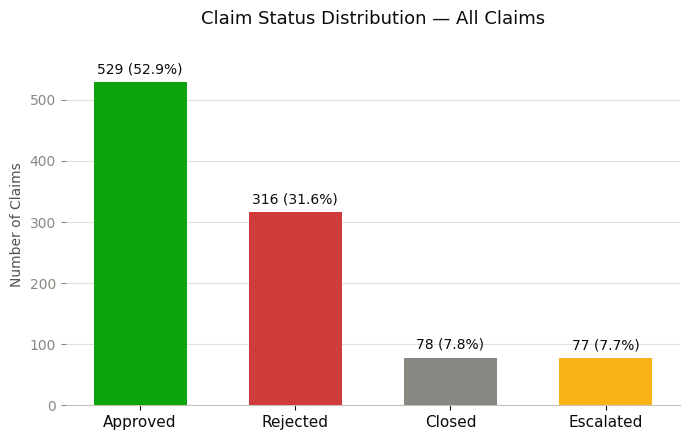

In [10]:
import matplotlib.pyplot as plt

# Semantic status colors: Approved=good, Rejected=critical, Escalated=warning, Closed=neutral
status_colors = {
    'Approved': '#0ca30c',
    'Rejected': '#d03b3b',
    'Escalated': '#fab219',
    'Closed': '#898781',
}

fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.bar(
    status_counts.index,
    status_counts.values,
    color=[status_colors.get(s, '#52514e') for s in status_counts.index],
    width=0.6,
    zorder=3,
)

for bar, count in zip(bars, status_counts.values):
    pct = count / total_claims * 100
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + total_claims * 0.01,
             f"{count} ({pct:.1f}%)", ha='center', va='bottom', fontsize=10, color='#0b0b0b')

ax.set_title('Claim Status Distribution — All Claims', fontsize=13, color='#0b0b0b', pad=14)
ax.set_ylabel('Number of Claims', color='#52514e')
ax.set_xlabel('')
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.spines['bottom'].set_color('#c3c2b7')
ax.tick_params(axis='x', colors='#0b0b0b', labelsize=11)
ax.tick_params(axis='y', colors='#898781')
ax.yaxis.grid(True, color='#e1e0d9', linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
ax.margins(y=0.12)
plt.tight_layout()
plt.show()

### Claim Status Distribution by Country

Unique countries in AddressCountry: 1


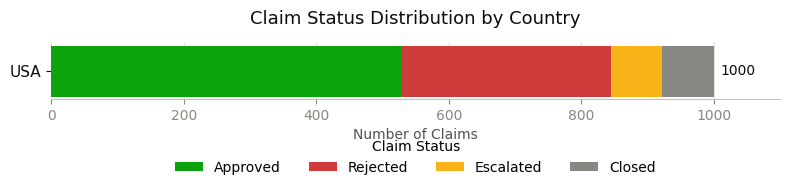

In [11]:
print("Unique countries in AddressCountry:", df['AddressCountry'].nunique())

country_status = pd.crosstab(df['AddressCountry'], df['ClaimStatus'])
country_status = country_status[[c for c in status_colors if c in country_status.columns]]

fig, ax = plt.subplots(figsize=(8, 2.2 + 0.6 * len(country_status)))
left = pd.Series(0, index=country_status.index)
for status in country_status.columns:
    ax.barh(country_status.index, country_status[status], left=left,
            color=status_colors.get(status, '#52514e'), label=status, height=0.5, zorder=3)
    left = left + country_status[status]

for i, country in enumerate(country_status.index):
    row_total = country_status.loc[country].sum()
    ax.text(row_total + row_total * 0.01, i, f"{row_total}", va='center', ha='left',
             fontsize=10, color='#0b0b0b')

ax.set_title('Claim Status Distribution by Country', fontsize=13, color='#0b0b0b', pad=14)
ax.set_xlabel('Number of Claims', color='#52514e')
ax.set_ylabel('')
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.spines['bottom'].set_color('#c3c2b7')
ax.tick_params(axis='y', colors='#0b0b0b', labelsize=11)
ax.tick_params(axis='x', colors='#898781')
ax.xaxis.grid(True, color='#e1e0d9', linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
ax.margins(x=0.1)
ax.legend(title='Claim Status', loc='upper center', bbox_to_anchor=(0.5, -0.5),
          ncol=4, frameon=False)
plt.tight_layout()
plt.show()

### Claim Status Distribution by City (Top 15 by Volume)

`AddressCity` has 470 unique values, most with only 1–6 claims, so plotting every city is unreadable. Showing the top 15 cities by total claim count instead.

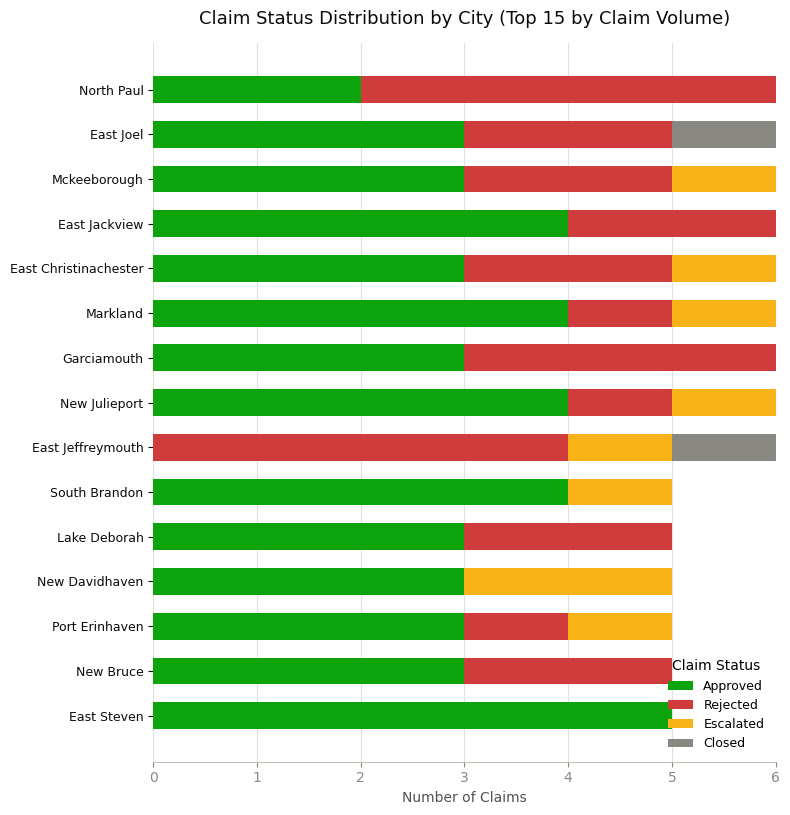

In [12]:
top_n = 15
top_cities = df['AddressCity'].value_counts().head(top_n).index

city_status = pd.crosstab(df['AddressCity'], df['ClaimStatus']).loc[top_cities]
city_status = city_status[[c for c in status_colors if c in city_status.columns]]
city_status = city_status.loc[city_status.sum(axis=1).sort_values(ascending=True).index]

fig, ax = plt.subplots(figsize=(8, 0.45 * len(city_status) + 1.5))
left = pd.Series(0, index=city_status.index)
for status in city_status.columns:
    ax.barh(city_status.index, city_status[status], left=left,
            color=status_colors.get(status, '#52514e'), label=status, height=0.6, zorder=3)
    left = left + city_status[status]

ax.set_title(f'Claim Status Distribution by City (Top {top_n} by Claim Volume)',
             fontsize=13, color='#0b0b0b', pad=14)
ax.set_xlabel('Number of Claims', color='#52514e')
ax.set_ylabel('')
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.spines['bottom'].set_color('#c3c2b7')
ax.tick_params(axis='y', colors='#0b0b0b', labelsize=9)
ax.tick_params(axis='x', colors='#898781')
ax.xaxis.grid(True, color='#e1e0d9', linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
ax.legend(title='Claim Status', loc='lower right', frameon=False, fontsize=9)
plt.tight_layout()
plt.show()

### Feature Correlation with Claim Rejections — North Paul

`North Paul` has only 6 total claims (2 Approved, 4 Rejected), so any correlation computed on it alone is statistically fragile. The cells below compute it anyway, then sanity-check the result against the full 1,000-claim dataset to see whether it's a real signal or a small-sample artifact.

In [ ]:
north_paul = df[df['AddressCity'] == 'North Paul'].copy()
north_paul['IsRejected'] = (north_paul['ClaimStatus'] == 'Rejected').astype(int)

print(f"North Paul claims: {len(north_paul)} total")
print(north_paul['ClaimStatus'].value_counts())

north_paul[['CaseID', 'ClaimStatus', 'ApprovalOrRejectionReason', 'ProofQualityFlag',
            'RestrictionsMatchFlag', 'AttachmentCompletenessScore']]

In [ ]:
import numpy as np

num_cols = north_paul.select_dtypes(include=[np.number]).columns.drop('IsRejected')
# require data on at least 4 of 6 rows and non-zero variance, otherwise the
# correlation is either undefined or based on too few points to mean anything
usable_cols = [c for c in num_cols
               if north_paul[c].notna().sum() >= 4 and north_paul[c].std() > 0]

corr_with_rejection = (
    north_paul[usable_cols]
    .corrwith(north_paul['IsRejected'])
    .dropna()
    .sort_values(key=lambda s: s.abs(), ascending=False)
)
corr_with_rejection.head(10).to_frame('Correlation with Rejection')

In [ ]:
for col in ['ProofQualityFlag', 'RestrictionsMatchFlag', 'FareOrRatePlanFlexibility']:
    print(f"--- {col} ---")
    print(pd.crosstab(north_paul[col], north_paul['ClaimStatus']))
    print()

In [ ]:
# Sanity check: does the North Paul pattern hold across the full 1,000-claim dataset?
print("ProofQualityFlag vs ClaimStatus, full dataset (row %):")
print(pd.crosstab(df['ProofQualityFlag'], df['ClaimStatus'], normalize='index').round(3))
print()

print("Mean AttachmentCompletenessScore by ClaimStatus, full dataset:")
print(df.groupby('ClaimStatus')['AttachmentCompletenessScore'].mean().round(3))

**Conclusion:** Within North Paul's 6 claims, `ProofQualityFlag` and `AttachmentCompletenessScore` appear to perfectly separate Approved from Rejected. But the full-dataset sanity check shows the *opposite* relationship — "Verified" proof quality and higher attachment completeness are both associated with **more** approvals dataset-wide, not more rejections. That confirms the North Paul correlation is a small-sample artifact, not a real driver.

The actual explanation for North Paul's rejections is in `ApprovalOrRejectionReason`: 3 of 4 are "Restrictions/flexibility do not match" and 1 is a blackout-date/excluded-fare issue — an operational pattern, not a statistical one.